Obter os dados:

In [1]:
from pathlib import Path
from scipy import stats
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

Primeiras cinco linhas do dataframe:

In [2]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Informação sobre as colunas do dataframe:

In [3]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Quantidade de itens para cada valor do atributo categórico "ocean_proximity"

In [4]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Método para ter uma visão geral dos dados: quantidade, média, desvio padrão, minimo, máximo e quartis:

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Média aparada:

In [6]:
stats.trim_mean(housing["housing_median_age"], 0.1)

np.float64(28.494549418604652)

Plotar histograma:

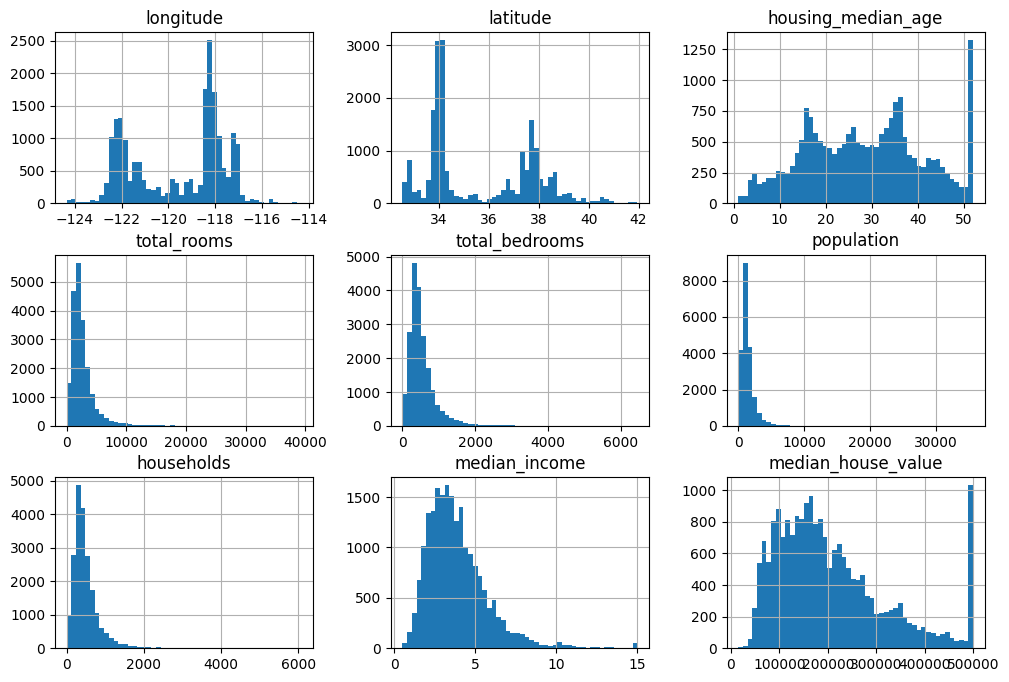

In [7]:
# bins = número de barras, figsize = tamanho da figura
housing.hist(bins=50, figsize=(12,8))
plt.show()

Criando conjunto de teste

In [8]:
# test_size = 0.2 significa que 20% dos dados serão usados para teste e random_state é usado para garantir que a divisão seja a mesma toda vez que o código for executado

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)


Criando um novo atributo categórico "income_cat":

**Stratified Shuffle Split** é uma técnica de amostragem que garante que a proporção de cada categoria em uma variável seja mantida tanto no conjunto de treinamento 
quanto no conjunto de teste. Isso é especialmente útil quando se tem uma variável categórica com classes desbalanceadas, pois ajuda a evitar que o modelo seja treinado ou testado com uma distribuição de classes diferente da real.

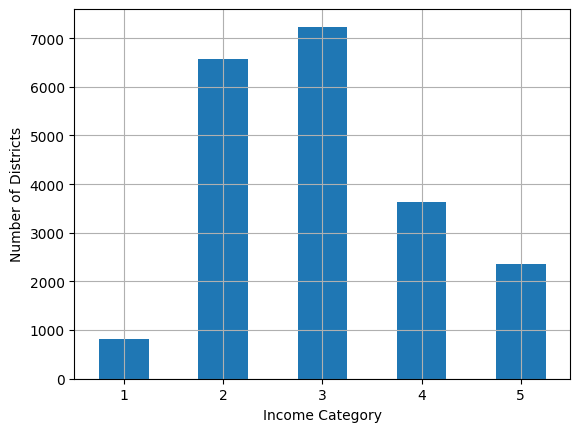

In [9]:
# pd.cut() é usado para segmentar e classificar os valores de renda em categorias, bins define os limites das categorias 
# e labels atribui um rótulo a cada categoria. Neste caso, estamos criando 5 categorias de renda com base na coluna "median_income" do DataFrame housing.

import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

housing["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

Dividindo os dados para teste e treinamento com base no atributo catégorico criando anteriormente (*Income Category*)

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_splits = []
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])


Forma mais curta de fazer o split estratificado usando o método `train_test_split`:

In [11]:
# Ou, alternativamente, usando train_test_split com o parâmetro stratify para garantir a estratificação com base na coluna "income_cat":

strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

Proporções das categorias de renda no conjunto de teste:

In [12]:
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

Excluir coluna *income_cat*, pois não será mais usada

In [13]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

Cópia do conjunto de treinamento para exploração:

In [14]:
housing = strat_train_set.copy()

## **<center>Visualizando dados geográficos</center>**

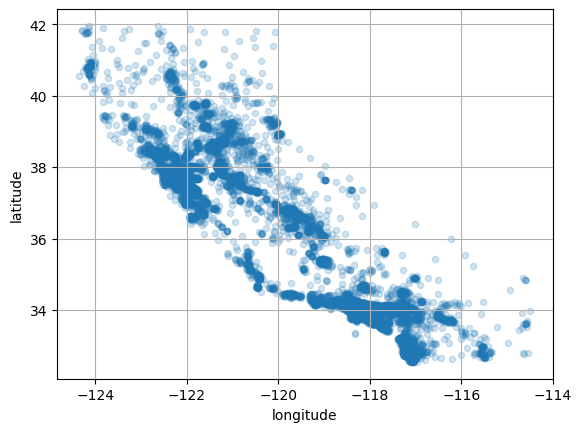

In [15]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

Incluindo preço dos imóveis usando o tamanho dos círculos:

- parâmetro s = é usado para definir o tamanho dos pontos no gráfico de dispersão, neste caso, estamos usando a coluna *population* dividida por 100 para ajustar o tamanho dos pontos. 
- parâmetro c = é usado para definir a cor dos pontos com base na coluna *median_house_value*, 
- cmap = "jet" define o mapa de cores a ser usado
- colorbar = True adiciona uma barra de cores ao gráfico para indicar os valores correspondentes às cores

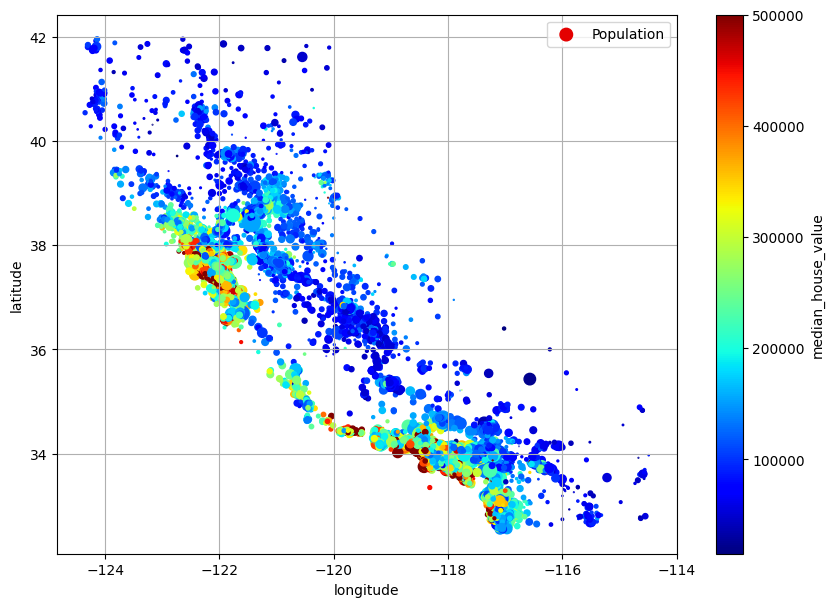

In [16]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, s=housing["population"]/100, label="Population", c="median_house_value",cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10,7))
plt.show()

- **Buscando correlações**:

Coeficiente de correlação padrão (também chamado de *r de Pearson*) entre cada par de atributos:

- Quanto mais próximo de 1.0: forte correlação positiva, quando um atributo aumenta o outro também aumenta
- Quanto mais próximo de -1.0: forte correlação negativa, quando um atributo aumenta o outro diminui
- Próximos de 0: não há correlação linear

In [17]:
corr_matrix = housing.corr(numeric_only=True)

O quanto cada atributo se correlaciona com o valor médio de um imóvel:

In [18]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Método para plotar cada atributo com relação a qualquer outro atributo numerico.
Usando só os atributos promissores:

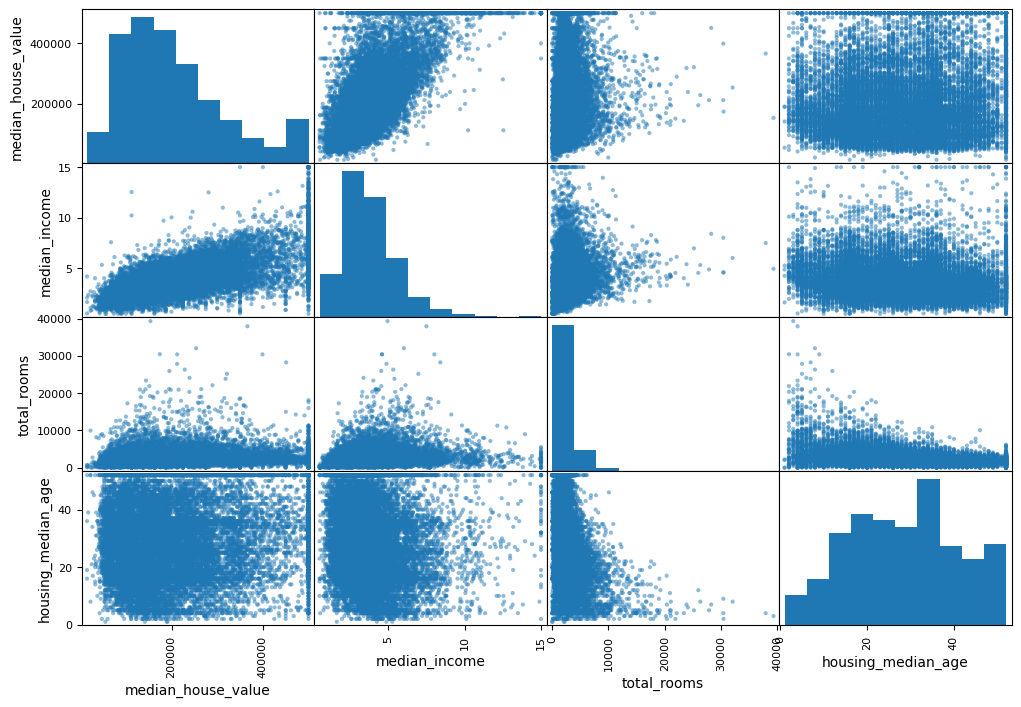

In [19]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

Gráfico de dispersão de correlação para o atributo mais promissor: renda média

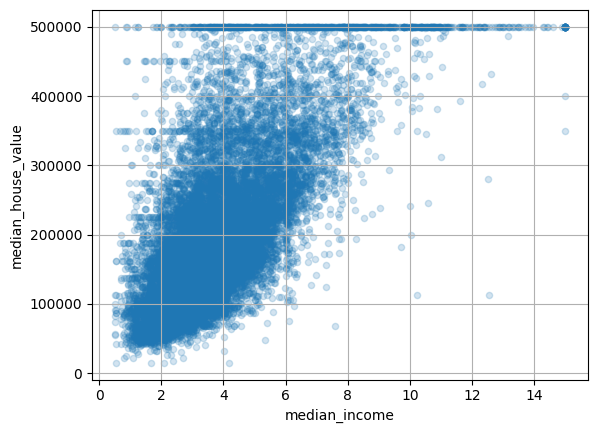

In [20]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", grid=True, alpha=0.2)
plt.show()

Novos atributos:

In [21]:
#Cômodos por família
housing["rooms_per_house"] = housing["total_rooms"]/housing["households"]

#Quartos por comôdos
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]

#População por domicilio
housing["people_per_house"] = housing["population"]/housing["households"]

Matrix de correlação:

In [22]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## **<center>Preparando os dados para Algoritmos ML</center>**

Revertendo para um conjunto de treinamento limpo e separando preditores e rótulos:

In [23]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

Para limpar os dados temos três opções:

- Excluir as linhas que tem valores nulos: `housing.dropna(subset=["total_bedrooms"], inplace=True)`
- Excluir a coluna toda: `housing.drop("total_bedrooms", axis=1)`
- Definir os valores para algum valor (média, mediana, zero, etc): <br>
`median = housing["total_bedrooms"].median()` <br>
`housing["total_bedrooms"].fillna(median, inplace=True)`

Se escolher a terceira opção, use o Scikit-Learn:

In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Cópia dos dados apenas com atributos numéricos:

In [25]:
housing_num = housing.select_dtypes(include=[np.number])

Usando o imputer para preencher os valores faltantes com a mediana de cada coluna numérica do DataFrame housing_num. O método *fit()* calcula a mediana de cada coluna, e o método *transform()* substitui os valores faltantes por essas medianas, retornando um array numpy com os dados preenchidos.

In [26]:
imputer.fit(housing_num)
imputer.statistics_
housing_num.median().values

X = imputer.transform(housing_num)
print(X)

# Criando um DataFrame a partir do array numpy resultante da transformação, mantendo as mesmas colunas e índices do DataFrame original housing_num para facilitar a análise e manipulação dos dados.
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

[[-1.2242e+02  3.7800e+01  5.2000e+01 ...  1.5760e+03  1.0340e+03
   2.0987e+00]
 [-1.1838e+02  3.4140e+01  4.0000e+01 ...  6.6600e+02  3.5700e+02
   6.0876e+00]
 [-1.2198e+02  3.8360e+01  3.3000e+01 ...  5.6200e+02  2.0300e+02
   2.4330e+00]
 ...
 [-1.1706e+02  3.2590e+01  1.3000e+01 ...  2.8140e+03  7.6000e+02
   4.0616e+00]
 [-1.1840e+02  3.4060e+01  3.7000e+01 ...  1.7250e+03  8.3800e+02
   4.1455e+00]
 [-1.2241e+02  3.7660e+01  4.4000e+01 ...  6.8200e+02  2.1200e+02
   3.2833e+00]]


**Manipulando Texto a Atributos Categóricos**

Algoritmos de ML preferem trabalhar com atributos numéricos, então vamos transformar o atributo categórico *ocean_proximity* em um atributo numérico:

In [28]:
housing_cat = housing[["ocean_proximity"]]

from sklearn.preprocessing import OrdinalEncoder

ordinal_enconder = OrdinalEncoder()
housing_cat_encoded = ordinal_enconder.fit_transform(housing_cat)
print(housing_cat_encoded[:10])
ordinal_enconder.categories_



[[3.]
 [0.]
 [1.]
 [1.]
 [4.]
 [1.]
 [0.]
 [3.]
 [0.]
 [0.]]


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Essa abordagem é boa quando os valores das categorias são ordenadas, por exemplo "ruim", "médio", "bom" e "excelente", porém esse não é o caso da coluna *ocean_proximity* (categorias 0-<1H OCEAN e 4-NEAR OCEAN são mais próximas que as categorias 1 e 2).Solução comum criar atributo binário por categoria:

um atributo com valor 1 para quando a categoria é <1H OCEAN e outro atributo com valor 1 quando a categoria é INLAND

Isso é chamado de codificação *one-hot* (ou codificação distribuída), os atributos novos se chamam atributos falsos (*dummy*)


In [30]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)

cat_encoder.categories_

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>
  Coords	Values
  (0, 3)	1.0
  (1, 0)	1.0
  (2, 1)	1.0
  (3, 1)	1.0
  (4, 4)	1.0
  (5, 1)	1.0
  (6, 0)	1.0
  (7, 3)	1.0
  (8, 0)	1.0
  (9, 0)	1.0
  (10, 1)	1.0
  (11, 0)	1.0
  (12, 0)	1.0
  (13, 1)	1.0
  (14, 4)	1.0
  (15, 0)	1.0
  (16, 1)	1.0
  (17, 3)	1.0
  (18, 1)	1.0
  (19, 0)	1.0
  (20, 0)	1.0
  (21, 4)	1.0
  (22, 1)	1.0
  (23, 3)	1.0
  (24, 1)	1.0
  :	:
  (16487, 1)	1.0
  (16488, 0)	1.0
  (16489, 0)	1.0
  (16490, 3)	1.0
  (16491, 1)	1.0
  (16492, 4)	1.0
  (16493, 4)	1.0
  (16494, 1)	1.0
  (16495, 0)	1.0
  (16496, 1)	1.0
  (16497, 0)	1.0
  (16498, 0)	1.0
  (16499, 4)	1.0
  (16500, 0)	1.0
  (16501, 0)	1.0
  (16502, 0)	1.0
  (16503, 0)	1.0
  (16504, 0)	1.0
  (16505, 0)	1.0
  (16506, 1)	1.0
  (16507, 0)	1.0
  (16508, 1)	1.0
  (16509, 4)	1.0
  (16510, 0)	1.0
  (16511, 4)	1.0


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

**Escalonamento das Características e Transformação**

Algoritmos ML não funcionam bem quando a escala dos atributos numéricos de entrada são muito diferentes. Duas formas comuns de resolver esse problema **escalonamento min-max** e **padronização**

- **Escalonamento min-max** (também chamado de **normalização**): para cada atributo, os valores são deslocados e reescalonados de modo que acabam variando de 0 a 1. Para fazer isso subtraírmos o valor mínimo e dividindo pela diferença entre o mínimo e o máximo.

In [33]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)


- **Padronização**: subtrai o valor médio, em seguida, divide o resultado pelo desvio-padrão. A padronização não restringe os valores a um intervalo especifíco, no entanto, é muito menos afetada por valores atípicos.

In [34]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

Também devemos transformar os alvos. A maioria dos transformadores do Scikit-Learn tem um método *inverse_transform()* que facilita o cálculo inverso de suas transformações:

In [35]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5] #fingir que são dados novos

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

Forma mais simples:

In [ ]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

**Transformadores Personalizados**

Exemplo de transformador log aplicado na caracteristica *populate*

In [ ]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])
